# **MLP & Backpropagation**

## Assignment Number : 2

- **Student Name**: Sanjay Pahari
- **Roll Number**: 42
- **Group**: Computer Engineering, 7th semester
- **Date**: 12 April 2026
- **Dataset Used**: Iris dataset from Kaggle
- **Resource Utilized**: d2l.ai

## **Objective**
This assigment focuses on understanding and implementing MLP from scratch along with loss function, backpropagation and training loop design. Below are some objectives that this assingments would achieve:

1. Build the basic MLP - Multilayer Percepton
2. Implement the loss function and backpropagation concept
3. Designing the training loop
4. Understand and implement the concept of Forward

## **Theoretical Background**

Just like human thinking process, Frank Rosenblatt developed a "Perceptron" for computers to think like human which was inspired from the neuron of human brain. 

### **Neuron and Perceptron**


![Fig: Perceptron](../assets/2/perceptron.png)

![Fig: Perceptron](../assets/2/inner.png)

Methodology that the multilayer perceptrons is inspired in learning to do something just like human does (maybe guessing the object):
1. Inital guess
2. Change the guess if not correct
3. Repeat

Actual working of MLP:
1. MLP gives an output
2. Change implies Back Propagation which means improve each layers from output to input based on the current output of the model
3. Repeat implies epoch which mean multilayer perceptrons go through mulitple training itereation to improve itself for accurate output

MLP is made of multiple layers of neurons:
a. Input layer
b. Hidden layers
c. Output layers

### **Learning Methods of MLP**

##### **Forward propagation**
This works for computing output.

The working of the Neural Network is basically called as Forward Propagation.

![Fig: Perceptron](../assets/2/perceptron2.png)

The propagation works like: Input -> Weight is multiplied -> Bias is added -> Activation Function is applied -> Weight is multipled -> Multi-path(connections) values are summed -> Bias is added-> Output

![Fig: Perceptron](../assets/2/mathfinal.png)

> **💡 Tip**
>   
> Get deeper into Forward Propagation i.e. [Basics of Neural Network](https://freaktopus.github.io/LearningDeep/chapters/neural_network/neural_network_basics.html)

##### **Loss Function**

Loss function are those type of functions that are used to measure how wrong the model's prediction is (measure the difference between the actual value and the predicted value of a model)

Some type of loss functions are: Sum of Squared Residuals, Mean Absolute Error, Huber Loss, Mean Squared Log Error etc.

##### **Backpropagation**

> **💡 Tips**  
> 
> Before diving into Backpropagation, get familar with the concept of [Chain rule and Gradient Descent](https://freaktopus.github.io/LearningDeep/chapters/neural_network/backpropagation.html)  

The core concepts behind the backpropagation is using gradient descent to the find the optimal value of the bias(b3) using learning rate, chain rule, derivate and loss function.

You will understand it better if you have gone through Chain Rule & Gradient Descent properly.

The screenshot below can illustrate the basic concept behind backpropagtion.


![Fig: Backpropagation](../assets/2/backpropagation1.png)

**Basic understanding of Backpropagation**

Assume optimal value of b3 in that figure is unknown. What we do next is, we assume 0 as initial value of b3 and find the SSR(Sum of Squared Residual) for the curve obtain from that particular bias value.

Then plot that SSR(y-axis) and Bias(x-axis) in a graph. Then take derivative of SSR with respect to the bias to find optimal value of bias.

![Fig: Backpropagation](../assets/2/backpropagation2.png)

Using Gradient Descent, we calcaulte optimal value for bias, which is obtain when step size (here it is for calculaitng the new bias value) is near 0.


## **Implementation**

So, let's built multi-layer perceptron, where it classify 3 types of iris flowers using 4 feature. 

Being honest, I have used LLM to help me code for implementing MLP form scratch. I ensure, all the step will be rewritten from my side with proper understanding.

*Note: The implemention in the Github repository will be updated with more advance version later on. The first submitted file will have very basic implementation code*

In [19]:
# Initialization

import numpy as np # Numpy is used for tensor operations. Discussed in assignment 1.
import kagglehub # Kaggle library to load dataset
from kagglehub import KaggleDatasetAdapter
import pandas as pd # library for data analysis & manipulation 
import matplotlib.pyplot as plt # library for creating static, animated and interactive visulatizations

### **Step 1:** 

#### Dataset Load

In [20]:
############################
# Remotely Load Iris Dataset
############################

# Loading Iris data form kagglehub
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "uciml/iris",
    "Iris.csv"
)

print(df.head())

/tmp/ipykernel_244382/1628867733.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


### **Step 2:** 

#### Data Work

In [21]:
############################
# Organizing & Normalizing the data
############################

# X is for feature
X = df.drop(columns=["Id", "Species"]).values
# y is for labels (output)
y = df["Species"].values

# Encoding the string labels for the species since NN can't understand strings
label_map = {}
label_id = 0
y_encoded = []

for label in y:
    if label not in label_map:
        label_map[label] = label_id
        label_id += 1
    y_encoded.append(label_map[label])

# conversion to numpy array (tensor)
y = np.array(y_encoded)

num_classes = len(label_map)

# Represention of species in array of len(species) i.e if 3 species then [0,1,0] or [1,0,0] or [0,0,1]
y_onehot = np.zeros((len(y), num_classes))
y_onehot[np.arange(len(y)), y] = 1

# Normalizing the feature so that features are in near scale
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

### **Step 3:** 

#### Split train and test

Split is done in 80/20 rule. Train data is 80% whereas test data is 20%

In [27]:
np.random.seed(42)
idx = np.random.permutation(len(X))

# Train data: 80% & Test Data:20%
split = int(0.8 * len(X))
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train_raw, y_test_raw = y[train_idx], y[test_idx]
# Conversion of train and test data to one hot encoding
y_train = np.eye(num_classes)[y_train_raw]
y_test  = np.eye(num_classes)[y_test_raw]

### **Step 4:** 

#### Define Activation Function

In [23]:
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

### **Step 5:** 

#### MLP Model Class

In [24]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    # forward pass
    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = softmax(self.z2)

        return self.a2

    # loss function
    def compute_loss(self, y_true, y_pred):
        return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))

    # backpropagation
    def backward(self, X, y, lr):
        m = X.shape[0]

        dz2 = self.a2 - y
        dW2 = self.a1.T @ dz2 / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = dz2 @ self.W2.T
        dz1 = da1 * relu_grad(self.z1)

        dW1 = X.T @ dz1 / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # update
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2

### **Step 6:** 

#### Training Loop 

In [11]:
def train(model, X, y, epochs, lr):
    losses = []

    for epoch in range(epochs):
        y_pred = model.forward(X)
        loss = model.compute_loss(y, y_pred)
        losses.append(loss)

        model.backward(X, y, lr)

        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return losses

### **Step 7:** 

#### Train Model 

In [12]:
model = MLP(input_size=4, hidden_size=8, output_size=3)

losses = train(model, X_train, y_train, epochs=500, lr=0.01)

Epoch 0, Loss: 1.0988
Epoch 50, Loss: 1.0980
Epoch 100, Loss: 1.0972
Epoch 150, Loss: 1.0962
Epoch 200, Loss: 1.0944
Epoch 250, Loss: 1.0912
Epoch 300, Loss: 1.0850
Epoch 350, Loss: 1.0733
Epoch 400, Loss: 1.0517
Epoch 450, Loss: 1.0149


### **Step 8:** 

#### Loss Plot

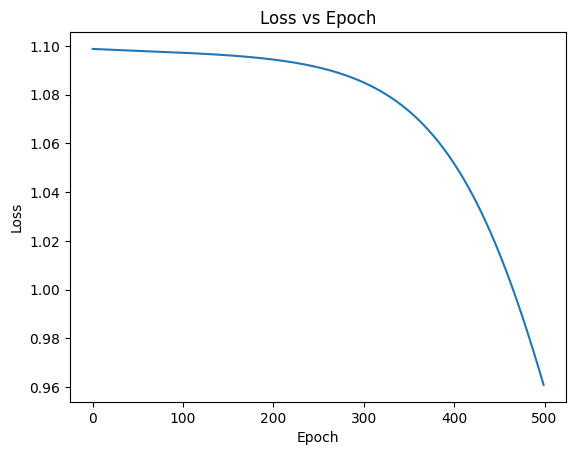

In [13]:
plt.plot(losses)
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

### **Step 9:** 

#### Accuracy Metric

In [14]:
def accuracy(model, X, y):
    pred = model.forward(X)
    pred_class = np.argmax(pred, axis=1)
    true_class = np.argmax(y, axis=1)
    return np.mean(pred_class == true_class)

train_acc = accuracy(model, X_train, y_train)
test_acc = accuracy(model, X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.35833333333333334
Test Accuracy: 0.23333333333333334


## **Dataset Description**

This assigment use any dataset from kaggle with following description of the dataset.

Source: Iris dataset from the UCI Machine Learning Repository, accessed via Kaggle (uciml/iris)  
Samples: 150  
Features: 4 (sepal length, sepal width, petal length, petal width)  
Classes: 3 (Setosa, Versicolor, Virginica)  
Split: 80% training, 20% testing (random shuffle)  

## **Experiments**


In [15]:
learning_rates = [0.1, 0.01, 0.001]
results = []

for lr in learning_rates:
    model = MLP(4, 8, 3)
    losses = train(model, X_train, y_train, epochs=300, lr=lr)
    acc = accuracy(model, X_test, y_test)
    results.append((lr, acc))

Epoch 0, Loss: 1.0986
Epoch 50, Loss: 1.0700
Epoch 100, Loss: 0.5042
Epoch 150, Loss: 0.3391
Epoch 200, Loss: 0.2641
Epoch 250, Loss: 0.2159
Epoch 0, Loss: 1.0986
Epoch 50, Loss: 1.0981
Epoch 100, Loss: 1.0976
Epoch 150, Loss: 1.0971
Epoch 200, Loss: 1.0966
Epoch 250, Loss: 1.0956
Epoch 0, Loss: 1.0986
Epoch 50, Loss: 1.0985
Epoch 100, Loss: 1.0985
Epoch 150, Loss: 1.0984
Epoch 200, Loss: 1.0984
Epoch 250, Loss: 1.0983


## **Results**

The ouput can be seen below:

In [25]:
for lr, acc in results:
    print("Learning Rate:", lr, "Test Accuracy:", acc)

Learning Rate: 0.1 Test Accuracy: 0.9333333333333333
Learning Rate: 0.01 Test Accuracy: 0.23333333333333334
Learning Rate: 0.001 Test Accuracy: 0.23333333333333334


## **Analysis & Discussion**

The insights from the experiments of hyperparameter tuning in neural networks are:

1. **Learning Rate Impact**: Initial model with lr=0.01 achieved only 23.3% test accuracy whereas lr=0.1 achieved 93.3% which demonstrates that learning rate is crucial for model convergence.

3. **Model Generalization**: The best model (lr=0.1) generalized well to unseen test data.

4. **Trade-off Observation**: When higher learning rates converge faster, they risk instability.

## **Conclusion**

The following points highlight key insights from this assignment:
1. From scratch, MLP is implemented using NumPy
2. Concepts like forward & backward propagation, loss functions, gradient descent were clearly understood
3. Learning rate concept and it's implementation with effect are observed.